### APS1070 Project 3 - Part 1, Git Practice

**Academic Integrity**

This project is individual - it is to be completed on your own. If you have questions, please post your query in the APS1070 Piazza Q&A forums (the answer might be useful to others!).

Do not share your code with others, or post your work online. Do not submit code that you have not written yourself. Students suspected of plagiarism on a project, midterm or exam will be referred to the department for formal discipline for breaches of the Student Code of Conduct.

Please fill out the following:


*   Your **name**: Ching (Jim) Chang
*   Your **student number**: 997755843



## Part 1: Getting started with GitHub [1.5 Marks + 2 Mark Git Submission]


For the first four parts (Part 1-4) of this project, we will work on a [population of countries dataset](https://ourworldindata.org/grapher/population) which reports the population of over 200 countries worldwide from 10000 BCE to 2023. Download the dataset in .csv format using the provided code below. Using the Pandas package, create a population dataframe with only the countries provided in [this GitHub list](https://raw.githubusercontent.com/Sabaae/Dataset/main/countries_list.txt) (237 countries - you should remove all other entities) as rows and years from 1901 to 2023 (123 years) as columns. Then, remove all the countries that have at least missing or invalid value over the years.

In [1]:
import pandas as pd
import requests, io

headers = {"User-Agent": "Mozilla/5.0"}
raw_data = pd.read_csv(
    filepath_or_buffer=io.StringIO(requests.get(
        'https://ourworldindata.org/grapher/population.csv?v=1&csvType=full&useColumnShortNames=true',
        headers=headers).text),
    index_col=False)

countries_list_url = "https://raw.githubusercontent.com/Sabaae/Dataset/main/countries_list.txt"

In [8]:
raw_data.head()

,entity,code,year,population_historical
0,Afghanistan,AFG,-10000,14737
1,Afghanistan,AFG,-9000,20405
2,Afghanistan,AFG,-8000,28253
3,Afghanistan,AFG,-7000,39120
4,Afghanistan,AFG,-6000,54166


In [19]:
### YOUR CODE HERE ###
countries_list = requests.get(countries_list_url).text.splitlines()

population = raw_data[raw_data["entity"].isin(countries_list) & raw_data["year"].between(1901, 2023)].copy()

population = population.pivot(index = "entity", columns = "year", values = "population_historical")

population = population.dropna(axis = 0, how = "any")

population.head()

year,1901,1902,1903,1904,1905,1906,1907,1908,1909,1910,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
entity,,,,,,,,,,,,,,,,,,,,,
Afghanistan,4751177.0,4802500.0,4861833.0,4921891.0,4982681.0,5044212.0,5106495.0,5169536.0,5300178.0,5504191.0,...,32792528.0,33831767.0,34700613.0,35688941.0,36743040.0,37856125.0,39068977.0,40000410.0,40578847.0,41454762.0
Albania,813539.0,821036.0,828461.0,835954.0,843514.0,851143.0,858841.0,866609.0,874016.0,881057.0,...,2903748.0,2898634.0,2897868.0,2898245.0,2894229.0,2885011.0,2871950.0,2849641.0,2827614.0,2811660.0
Algeria,4787149.0,4859600.0,4939332.0,5020372.0,5102742.0,5186463.0,5271557.0,5358048.0,5433528.0,5497750.0,...,39205035.0,40019528.0,40850719.0,41689302.0,42505033.0,43294551.0,44042094.0,44761099.0,45477391.0,46164222.0
Andorra,4551.0,4581.0,4610.0,4640.0,4670.0,4700.0,4730.0,4761.0,4802.0,4855.0,...,73755.0,72195.0,72197.0,73780.0,75181.0,76492.0,77397.0,78379.0,79722.0,80869.0
Angola,3083888.0,3064493.0,3043335.0,3022320.0,3001447.0,2980714.0,2960121.0,2939666.0,2921666.0,2906100.0,...,27160767.0,28157802.0,29183072.0,30234836.0,31297160.0,32375633.0,33451139.0,34532427.0,35635028.0,36749909.0


1. Write a function to do the following: **[0.5]**
    * Takes the dataframe, and your list of countries/regions as inputs (Afghanistan, Albania, Algeria, ...)
    * Plots time-series for the input list (it is best to plot each country in a separate graph (subplot), so you can easily compare them.)
    
2. Apply `StandardScaler` to the data. Each year should have a `mean` of zero and a `StD` of 1. **[0.25]**
3. Pick two countries whose names are closest to your first name using string edit distance.
Hint: you can use `Levenshtein.distance()` from the python-Levenshtein package. You may find [this link](https://www.geeksforgeeks.org/python/introduction-to-python-levenshtein-module/) helpful.
4. Run the function in `step 1` on both the original as well as the standardized dataset for the two countries you picked in `step 3` plus `Japan`, `Bosnia and Herzegovina`, `Latvia`, and `United Arab Emirates`. (If you have already selected one of these countries, go down the list and pick the next one you haven't selected) **[0.25]**
5. Discuss the trends in the standardized time-series for all these countries. What does it mean if the curve goes up or down? What does the sign of values indicate? **[0.5]**

In [28]:
### YOUR CODE HERE ###

# Question 1
import matplotlib.pyplot as plt

def plot_countries(population, countries):
  n = len(countries)

  fig, axes = plt.subplots(nrows = n, ncols = 1, figsize = (10, 4 * n))

  if n == 1:
    axes = [axes]

  for i, country in zip(axes, countries):
    i.plot(population.columns, population.loc[country])
    i.set_title(country)
    i.set_xlabel("Year")
    i.set_ylabel("Population")
    i.grid(True)

  plt.tight_layout()
  plt.show()

In [29]:
# Question 2
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

population_scaled = pd.DataFrame(scaler.fit_transform(population), index = population.index, columns = population.columns)

population_scaled.head()

year,1901,1902,1903,1904,1905,1906,1907,1908,1909,1910,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
entity,,,,,,,,,,,,,,,,,,,,,
Afghanistan,-0.100165,-0.100047,-0.099763,-0.099484,-0.099208,-0.098936,-0.098672,-0.098414,-0.096248,-0.092059,...,-0.034059,-0.029623,-0.026427,-0.022423,-0.017953,-0.013063,-0.007375,-0.003373,-0.001763,0.001713
Albania,-0.210133,-0.210609,-0.211095,-0.211588,-0.212088,-0.212596,-0.213114,-0.213642,-0.214023,-0.214260,...,-0.246648,-0.247677,-0.248635,-0.249513,-0.250503,-0.251641,-0.252834,-0.254159,-0.255592,-0.257056
Algeria,-0.099160,-0.098461,-0.097624,-0.096782,-0.095934,-0.095080,-0.094224,-0.093365,-0.092700,-0.092229,...,0.011552,0.013996,0.016545,0.019132,0.021633,0.024039,0.026348,0.028763,0.031174,0.033249
Andorra,-0.232726,-0.233281,-0.233835,-0.234396,-0.234965,-0.235540,-0.236126,-0.236721,-0.237152,-0.237421,...,-0.266777,-0.267602,-0.268379,-0.269074,-0.269870,-0.270801,-0.271785,-0.272866,-0.274068,-0.275342
Angola,-0.146728,-0.148310,-0.149959,-0.151601,-0.153239,-0.154871,-0.156500,-0.158127,-0.159538,-0.160733,...,-0.074116,-0.069620,-0.064978,-0.060195,-0.055368,-0.050451,-0.045471,-0.040285,-0.035004,-0.029793


In [30]:
# Question 3
!pip install python-Levenshtein

from Levenshtein import distance

first_name = "Jim"

country_distances = [ (country, distance(first_name.lower(), country.lower())) for country in population.index ]

country_distances.sort(key = lambda x: x[1])

closest_countries = [ country for country, distance in country_distances[:2] ]

print("\nTwo Closest Countries:", closest_countries)
print("Distances:", country_distances[:2])


Two Closest Countries: ['Fiji', 'Benin']
Distances: [('Fiji', 3), ('Benin', 4)]


Original Dataset


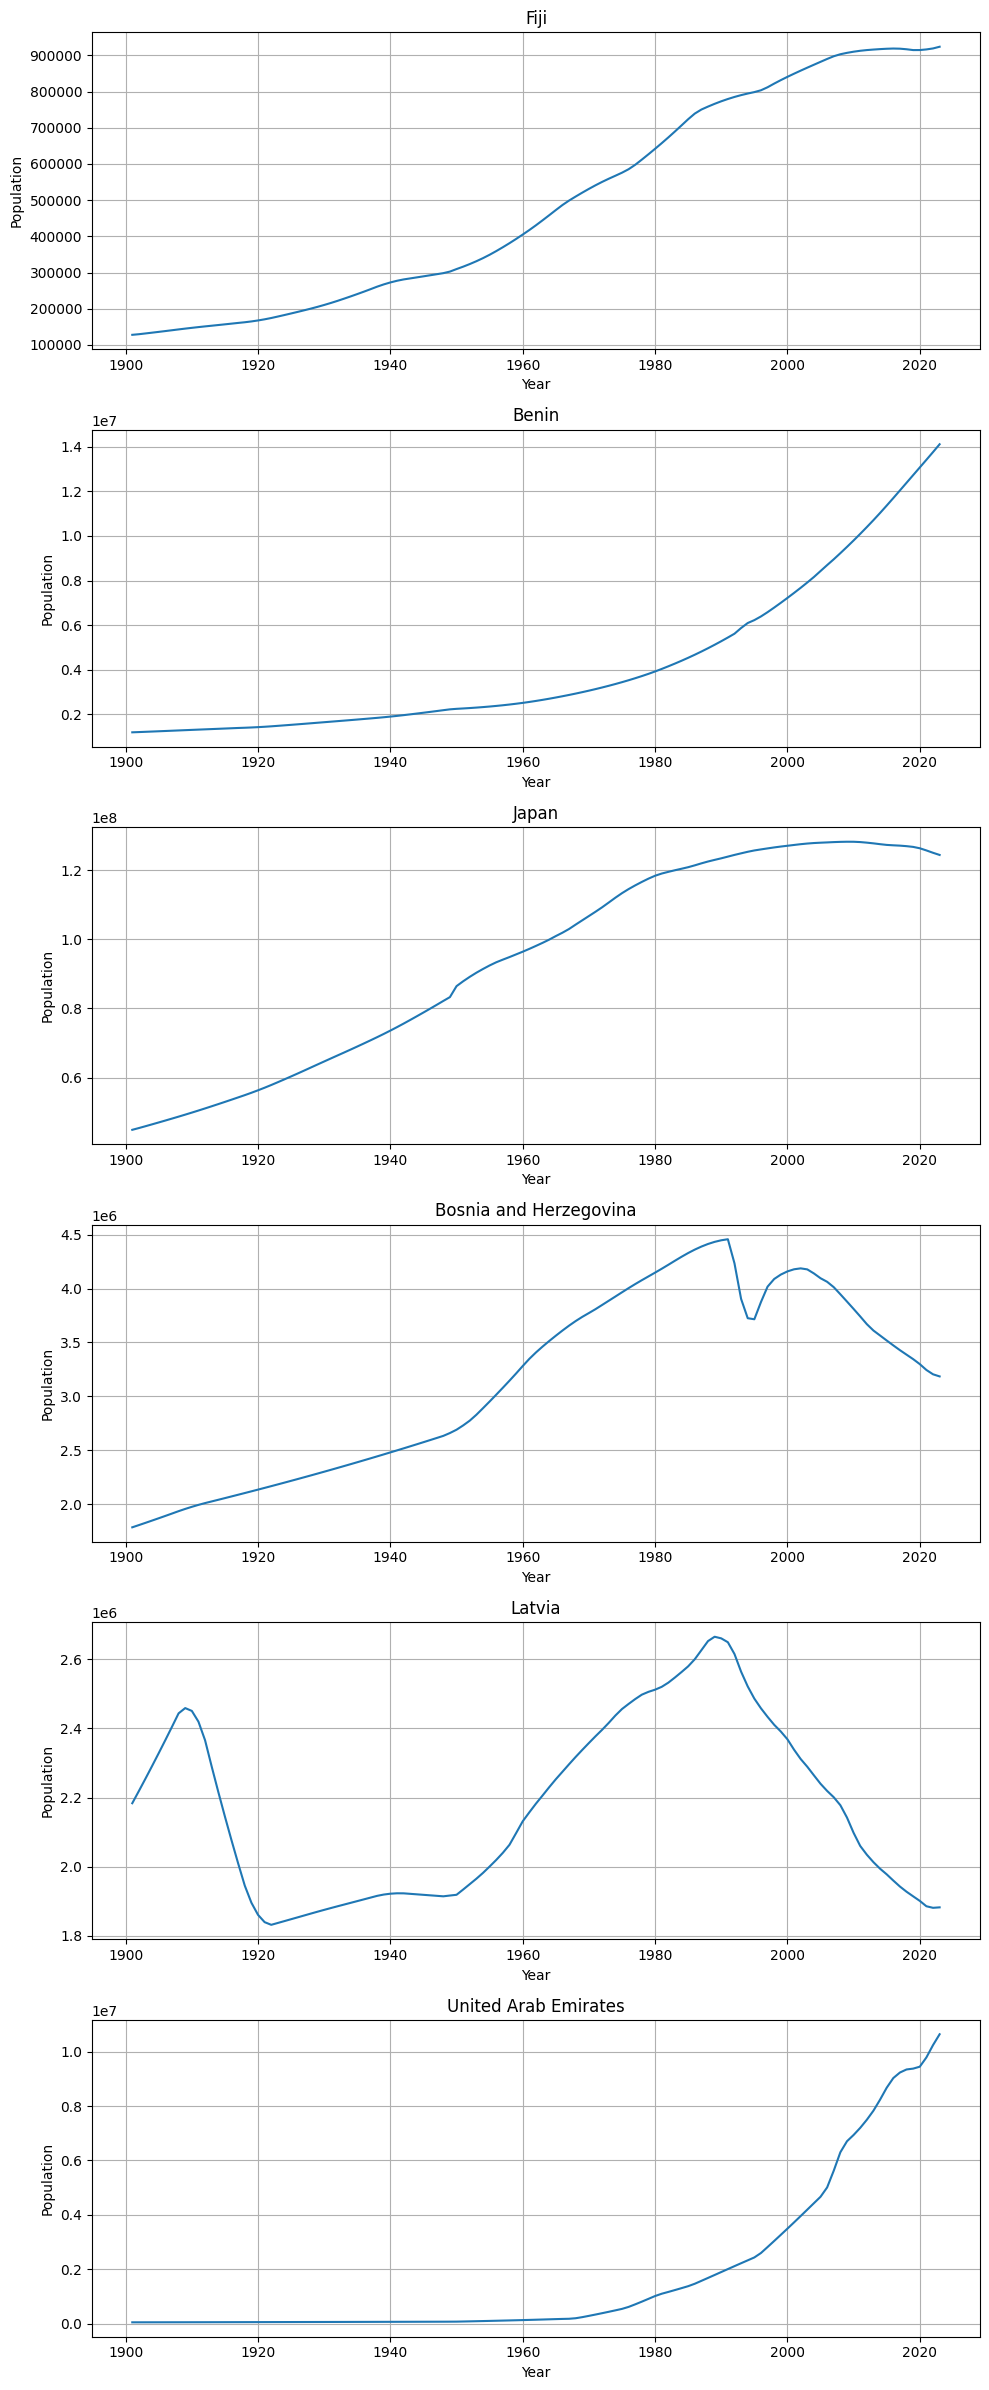

Standardized Dataset


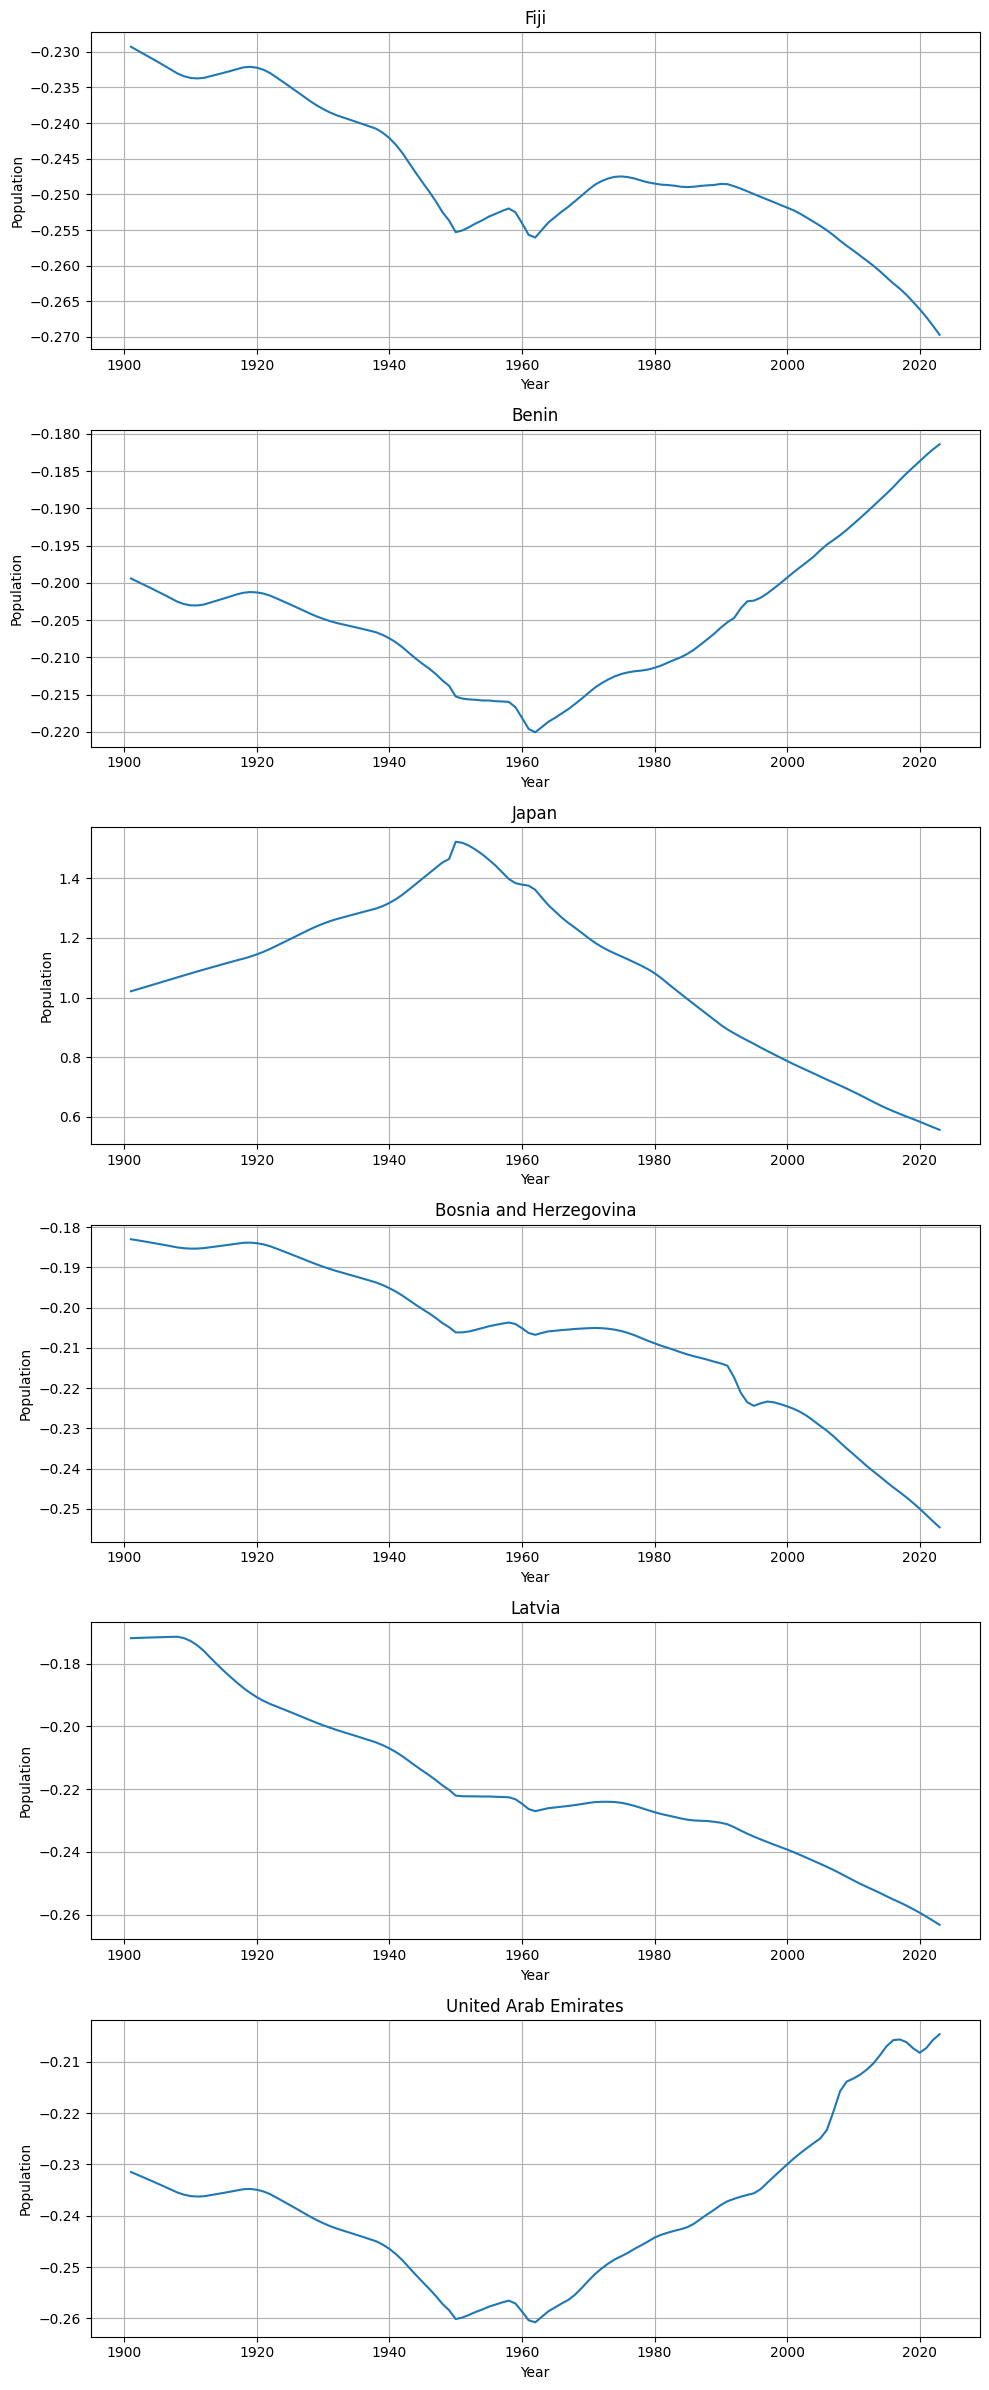

In [27]:
# Question 4
countries_to_plot = closest_countries + ["Japan", "Bosnia and Herzegovina", "Latvia", "United Arab Emirates"]

print("Original Dataset")
plot_countries(population, countries_to_plot)

print("Standardized Dataset")
plot_countries(population_scaled, countries_to_plot)

### Question 5

From the plots above, we can see that Japan remains above average throughout the period, although its relative position declines after about 1950. Benin and the United Arab Emirates show upward trends, suggesting that their populations have grown faster than the average country. Fiji, Bosnia and Herzegovina, and Latvia generally show downward trends, indicating that their populations have become smaller relative to the global average over the years.

The standardized time-series show how each contry's population compares to the average population across all countries in a given year. As each year has been transformed to have a mean of 0 and a standard deviation of 1, the curves no longer represent the actual population sizes, but rather the relative position of each country compared to others.
- if a curve goes up over time, it means that the country's population is becoming larger relative to the average country in the dataset
- if a curve goes down over time, it means the country's population is becoming smaller relative to the average country in the dataset

The sign of the value indicates whether the population is above or below the yearly average:
- positive values (> 0) suggest that the country's population is above the mean population for that year
- negative values (< 0) suggest that the country's population is below the mean population for that year
- a value close to 0 suggests that the country's population is close to the average population for that year